In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import matplotlib.colors as mcolors

In [98]:
df = pd.read_csv('fan.csv')
print((df.head()))

        B             I      T        VG           Vxx       Vxy
0  3.0005  1.050000e-08  1.869 -10.00000  6.050000e-07 -0.000029
1  3.0005  1.050000e-08  1.793  -9.97998  8.180000e-07 -0.000029
2  3.0005  1.050000e-08  1.793  -9.95996  6.900000e-07 -0.000029
3  3.0005  1.050000e-08  1.793  -9.93994  7.600000e-07 -0.000029
4  3.0005  1.050000e-08  1.793  -9.91992  8.530000e-07 -0.000029


In [99]:
df = df.dropna()
len(df['I']==None)

222026

In [100]:
df['Rxx'] = df['Vxx'] / df['I']

df = df.copy()
df.loc[df['Rxx'] <= 0, 'Rxx'] = 1e-3

df['ln_Rxx'] = np.log(df['Rxx'])

In [101]:
print(df.loc[df['Rxx'] <= 0, 'Rxx'].describe())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Rxx, dtype: float64


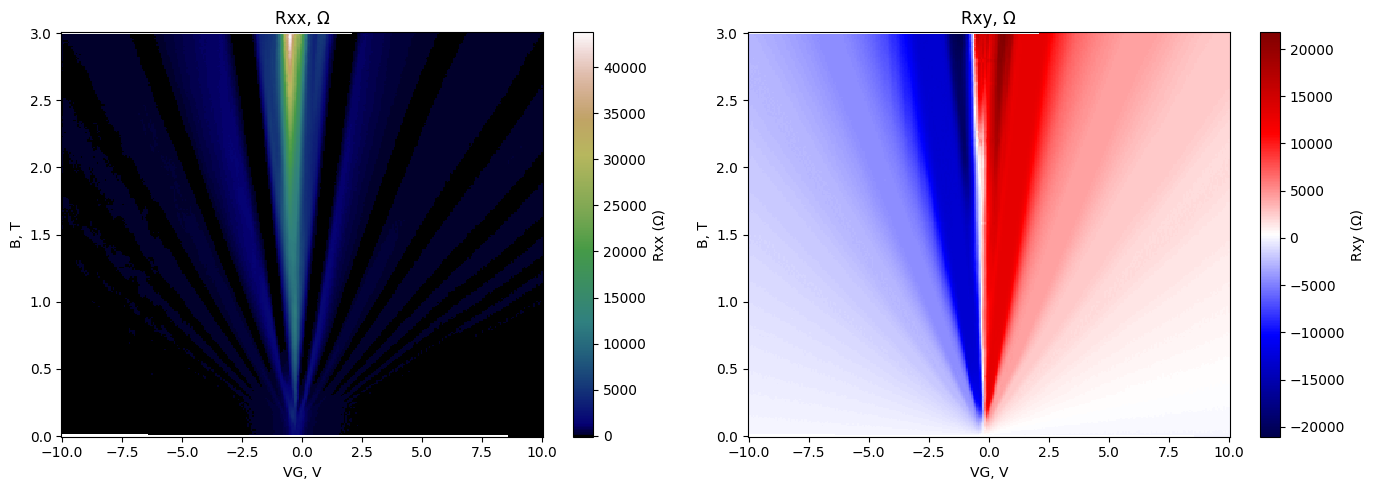

In [102]:
df['Rxx'] = df['Vxx'] / df['I']
df['Rxy'] = df['Vxy'] / df['I']

VG_grid, B_grid = np.meshgrid(
    np.linspace(df['VG'].min(), df['VG'].max(), 300),
    np.linspace(df['B'].min(),  df['B'].max(),  300),
)
Rxx_grid = griddata(
    (df['VG'], df['B']), df['Rxx'],
    (VG_grid, B_grid), method='linear',
)
Rxy_grid = griddata(
    (df['VG'], df['B']), df['Rxy'],
    (VG_grid, B_grid), method='linear',
)

Rxx_grid_log = griddata(
    (df['VG'], df['B']),df['ln_Rxx'],
    (VG_grid, B_grid), method='linear',
)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(VG_grid, B_grid, Rxx_grid, shading='auto', cmap='gist_earth')
fig.colorbar(im1, ax=axes[0], label='Rxx (Ω)')
axes[0].set_xlabel('VG, V')
axes[0].set_ylabel('B, T')
axes[0].set_title('Rxx, Ω')

im2 = axes[1].pcolormesh(VG_grid, B_grid, Rxy_grid, shading='auto', cmap='seismic')
fig.colorbar(im2, ax=axes[1], label='Rxy (Ω)')
axes[1].set_xlabel('VG, V')
axes[1].set_ylabel('B, T')
axes[1].set_title('Rxy, Ω')

plt.tight_layout()
plt.show()

fig.savefig('fan_Rxx_Rxy.png', dpi=300)

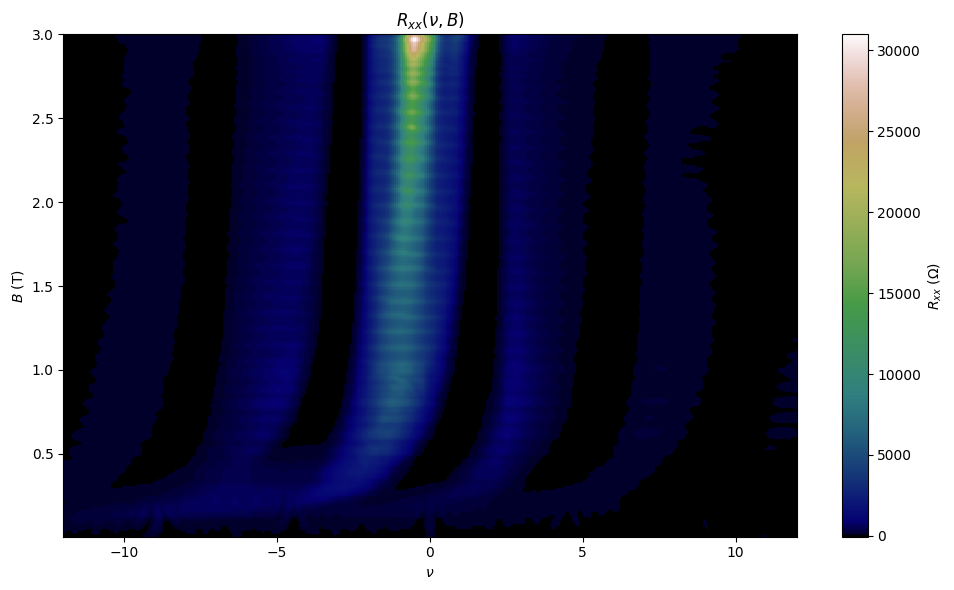

In [110]:

from scipy.ndimage import gaussian_filter

df = pd.read_csv('fan.csv')

e = 1.602e-19
h = 6.626e-34
Cg = 1.2e-4  # F/m^2

df['n']   = Cg * df['VG'] / e
df['Rxx'] = df['Vxx'] / df['I']

# Drop B=0 and restrict to high field
df['nu'] = df['n'] * h / (e * df['B'])

df = df[np.abs(df['nu']) < 12].copy()
df = df[np.isfinite(df['nu'])].copy()
df_filtered = df.copy()


# Bin
nu_bins = np.linspace(df['nu'].min(), df['nu'].max(), 400)
B_bins  = np.linspace(df['B'].min(),  df['B'].max(),  400)

df['nu_bin'] = pd.cut(df['nu'], bins=nu_bins, labels=(nu_bins[:-1] + nu_bins[1:]) / 2)
df['B_bin']  = pd.cut(df['B'],  bins=B_bins,  labels=(B_bins[:-1]  + B_bins[1:])  / 2)

df['nu_bin'] = df['nu_bin'].astype(float)
df['B_bin']  = df['B_bin'].astype(float)

pivot = df.groupby(['B_bin', 'nu_bin'])['Rxx'].mean().unstack('nu_bin')

smoothed = gaussian_filter(np.nan_to_num(pivot.values), sigma=2)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    pivot.columns.astype(float),
    pivot.index.astype(float),
    smoothed,
    cmap='gist_earth',
    shading='auto',
)
plt.colorbar(im, ax=ax, label=r'$R_{xx}$ ($\Omega$)')
ax.set_xlabel(r'$\nu$')
ax.set_ylabel(r'$B$ (T)')
ax.set_xlim(-12, 12)

ax.set_title(r'$R_{xx}(\nu, B)$')
plt.tight_layout()
plt.savefig('Rxx_nu_B.png', dpi=150)
plt.show()

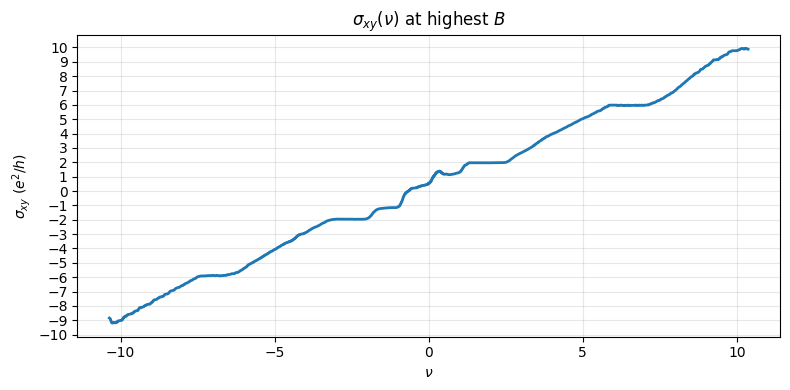

In [117]:
# --------------------------------------------
# Conductivity at highest magnetic field
# --------------------------------------------

# Hall resistance
df['Rxy'] = df['Vxy'] / df['I']

# Pick highest-B slice
Bmax = df['B'].max()

# take narrow window around highest field
dB = 0.02  # Tesla window
highB = df[np.abs(df['B'] - Bmax) < dB].copy()

# conductivity tensor inversion
denom = highB['Rxx']**2 + highB['Rxy']**2

highB['sigma_xx'] = highB['Rxx'] / denom
highB['sigma_xy'] = highB['Rxy'] / denom

# convert to units of e^2/h
e = 1.602e-19
h = 6.626e-34

sigma0 = e**2 / h

highB['sigma_xy_e2h'] = highB['sigma_xy'] / sigma0

# sort by filling factor
highB = highB.sort_values('nu')

# optional smoothing
from scipy.ndimage import gaussian_filter1d

smooth_sigma = gaussian_filter1d(
    highB['sigma_xy_e2h'].values,
    sigma=2
)

# --------------------------------------------
# Plot
# --------------------------------------------

fig, ax = plt.subplots(figsize=(8,4))


plt.plot(
    highB['nu'],
    smooth_sigma,
    lw=2
)

plt.xlabel(r'$\nu$')
plt.ylabel(r'$\sigma_{xy}$ ($e^2/h$)')
plt.title(r'$\sigma_{xy}(\nu)$ at highest $B$')

plt.grid(alpha=0.3)

import numpy as np
ax = plt.gca()
ymin, ymax = ax.get_ylim()
ax.set_yticks(np.arange(np.ceil(ymin), np.floor(ymax) + 1, 1))

plt.tight_layout()
plt.show()
fig.savefig('fan_sigma_xy.png', dpi=300)

In [206]:
e = 1.602e-19
h = 6.626e-34
epsilon_0 = 8.854e-12
epsilon_r = 3.9
dalpha = 3.56-2.17
d = epsilon_0 * epsilon_r *dalpha*h/4/e**2
d

3.0980280217378086e-07

In [207]:
p = 4*e/dalpha/h
print(f"p = {p:.2e} m^-2/V")

p = 6.96e+14 m^-2/V


     B_3V  Binv_3V        I_X_3V        Vxx_3V  Rxx_3V    B_5V   Binv_5V  \
0  1.0002   0.9998  2.090000e-08  4.480000e-07    21.4  2.0004  0.499900   
1  1.0002   0.9998  2.090000e-08  4.570000e-07    21.8  2.0004  0.499900   
2  1.0002   0.9998  2.090000e-08  4.440000e-07    21.2  2.0004  0.499900   
3  1.0002   0.9998  2.090000e-08  4.680000e-07    22.3  2.0004  0.499900   
4  1.0002   0.9998  2.090000e-08  4.480000e-07    21.4  1.9999  0.500025   

         I_X_5V    Vxx_5V  Rxx_5V  ...   B_45V  Binv_45V       I_X_45V  \
0  1.050000e-08  0.000002   186.0  ...  1.5002  0.666578  5.240000e-08   
1  1.050000e-08  0.000002   187.0  ...  1.4998  0.666756  5.240000e-08   
2  1.050000e-08  0.000002   201.0  ...  1.4996  0.666844  5.240000e-08   
3  1.050000e-08  0.000002   198.0  ...  1.4994  0.666933  5.240000e-08   
4  1.050000e-08  0.000002   187.0  ...  1.4992  0.667022  5.240000e-08   

        Vxx_45V  Rxx_45V   B_60V     Binv_60V       I_X_60V       Vxx_60V  \
0  2.600000e-07     4

In [83]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.signal import detrend
from numpy.fft import fft, fftfreq
import matplotlib.cm as cm

e = 1.602176634e-19
h = 6.62607015e-34

df = pd.read_csv("sdh.csv")

gate_voltages = sorted(
    [col.split("_")[-1] for col in df.columns if "Rxx_" in col],
    key=lambda x: float(x.replace("V", ""))
)

VG_numeric = np.array([float(v.replace("V", "")) for v in gate_voltages])

cmap = cm.get_cmap("cividis_r")

n_dict = {}

fig = go.Figure()

for VG in gate_voltages:

    try:
        Binv = pd.to_numeric(df[f"Binv_{VG}"], errors="coerce").values
        Rxx  = pd.to_numeric(df[f"Rxx_{VG}"], errors="coerce").values
    except KeyError:
        continue

    idx = np.argsort(Binv)
    x = Binv[idx]
    y = Rxx[idx]

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 10:
        continue

    VG_float = float(VG.replace("V", ""))

    t = (VG_float - VG_numeric.min()) / (VG_numeric.max() - VG_numeric.min())
    r, g, b = (np.array(cmap(t)[:3]) * 255).astype(int)
    color = f"rgb({int(r)},{int(g)},{int(b)})"

    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            name=VG,
            line=dict(color=color)
        )
    )

    dx = np.mean(np.diff(x))
    y_detrended = detrend(y)

    yf = fft(y_detrended)
    xf = fftfreq(len(x), d=dx)

    pos = xf > 0
    xf = xf[pos]
    yf = np.abs(yf[pos])

    if len(xf) == 0:
        continue

    F = xf[np.argmax(yf)]
    n = (2 * e / h) * F

    n_dict[VG_float] = n

fig.update_layout(
    xaxis_title="1/B (T^-1)",
    yaxis_title="Rxx (Ohm)",
    template="plotly_white"
)

fig.show()

n_sorted = dict(sorted(n_dict.items()))

fig2 = go.Figure()
fig2.add_trace(
    go.Scatter(
        x=list(n_sorted.keys()),
        y=list(n_sorted.values()),
        mode="lines+markers"
    )
)

fig2.update_layout(
    xaxis_title="Gate Voltage VG (V)",
    yaxis_title="Carrier density n (m^-2)",
    template="plotly_white"
)

fig2.show()

/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_64609/2425220556.py:20: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

divide by zero encountered in matmul

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

overflow encountered in matmul

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

invalid value encountered in matmul



/var/folders/5h/80_mph8s1tg289gn7wkq8qq00000gn/T/ipykernel_64609/1654144308.py:22: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

divide by zero encountered in matmul

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

overflow encountered in matmul

/Users/goikhmanb/Library/Python/3.9/lib/python/site-packages/scipy/signal/_signaltools.py:3602: RuntimeWarning:

invalid value encountered in matmul



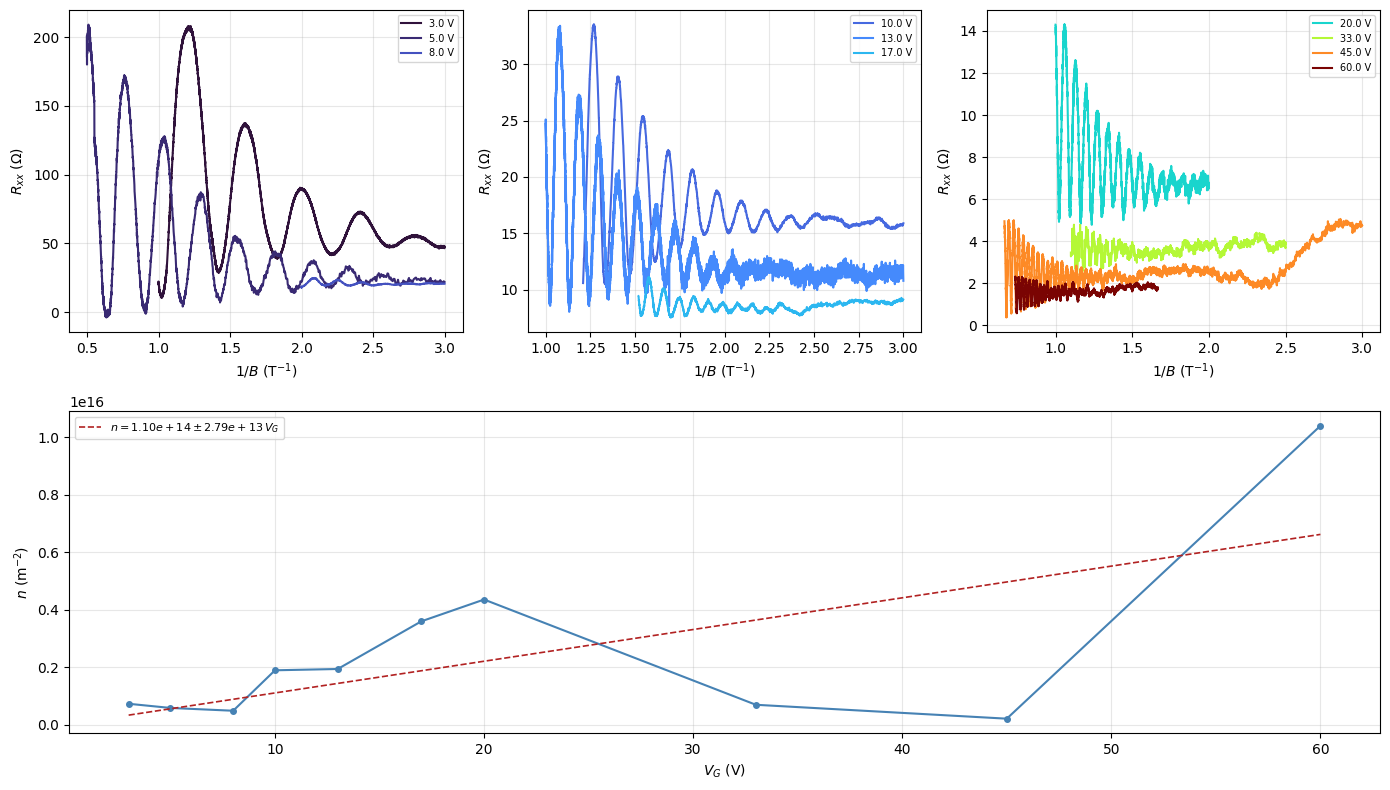

In [197]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MultipleLocator
from scipy.signal import detrend
from numpy.fft import fft, fftfreq

e = 1.602176634e-19
h = 6.62607015e-34

df = pd.read_csv("sdh.csv")


gate_voltages = sorted(
    [col.split("_")[-1] for col in df.columns if "Rxx_" in col],
    key=lambda x: float(x.replace("V", ""))
)

VG_numeric = np.array([float(v.replace("V", "")) for v in gate_voltages])

cmap = cm.get_cmap("turbo")

# --- collect traces and compute n(VG) ---
traces = []  # list of (VG_float, x, y, color)
n_dict = {}

for VG in gate_voltages:
    try:
        Binv = pd.to_numeric(df[f"Binv_{VG}"], errors="coerce").values
        Rxx  = pd.to_numeric(df[f"Rxx_{VG}"],  errors="coerce").values
    except KeyError:
        continue

    idx  = np.argsort(Binv)
    x, y = Binv[idx], Rxx[idx]
    mask = np.isfinite(x) & np.isfinite(y)& (Binv[idx] < 3)
    x, y = x[mask], y[mask]

    if len(x) < 10:
        continue

    VG_float = float(VG.replace("V", ""))
    t = (VG_float - VG_numeric.min()) / (VG_numeric.max() - VG_numeric.min())
    color = cmap(t)

    traces.append((VG_float, x, y, color))

    dx         = np.mean(np.diff(x))
    y_detrended = detrend(y)
    yf         = fft(y_detrended)
    xf         = fftfreq(len(x), d=dx)
    pos        = xf > 0
    xf, yf     = xf[pos], np.abs(yf[pos])
    if len(xf) == 0:
        continue
    F = xf[np.argmax(yf)]
    n_dict[VG_float] = (2 * e / h) * F

# --- split 10 traces into groups of 3, 3, 4 ---
groups = [traces[:3], traces[3:6], traces[6:]]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, group in enumerate(groups):
    ax = axes[0, col]
    for VG_float, x, y, color in group:
        ax.plot(x, y, lw=1.5, color=color, label=f"{VG_float} V")
    ax.set_xlabel(r"$1/B$ (T$^{-1}$)")
    ax.set_ylabel(r"$R_{xx}$ ($\Omega$)")
    ax.legend(fontsize=7, loc="best")
    ax.grid(alpha=0.3)

# hide the third lower axis slot if only 2 lower plots needed,
# but here we only have one lower plot spanning all three columns
for col in range(3):
    axes[1, col].set_visible(False)

# n(VG) spanning the full lower row

ax_n = fig.add_subplot(2, 1, 2)

n_sorted = dict(sorted(n_dict.items()))
vg_arr = np.array(list(n_sorted.keys()))
n_arr  = np.array(list(n_sorted.values()))

slope = np.dot(vg_arr, n_arr) / np.dot(vg_arr, vg_arr)
n_fit = slope * vg_arr
residuals = n_arr - n_fit
slope_err = np.sqrt(np.dot(residuals, residuals) / (len(n_arr) - 1) / np.dot(vg_arr, vg_arr))


ax_n.plot(vg_arr, n_arr, lw=1.5, marker="o", ms=4, color="steelblue")
ax_n.plot(vg_arr, n_fit, lw=1.2, ls="--", color="firebrick",
          label=rf"$n = {slope:.2e} \pm {slope_err:.2e} \,V_G$")
ax_n.set_xlabel(r"$V_G$ (V)")
ax_n.set_ylabel(r"$n$ (m$^{-2}$)")
ax_n.legend(fontsize=8)
ax_n.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('sdh_traces_and_density.png', dpi=300)

In [180]:
import numpy as np
import pandas as pd
from scipy.signal import detrend, find_peaks

e = 1.602176634e-19
hbar = 1.054571817e-34
vF = 1e6

def extract_tauq_graphene(Binv, Rxx, n):
    idx = np.argsort(Binv)
    x = Binv[idx]
    y = Rxx[idx]

    finite_mask = np.isfinite(x) & np.isfinite(y) & (Binv[idx] < 3)
    x = x[finite_mask]
    y = y[finite_mask]

    if len(x) < 10:
        return np.nan

    y_osc = detrend(y)

    peaks, _ = find_peaks(y_osc)
    if len(peaks) < 5:
        return np.nan

    Binv_peaks = x[peaks]          # 1/B at each peak
    A = np.abs(y_osc[peaks])

    amp_mask = (A > 0) & np.isfinite(A)
    Binv_peaks = Binv_peaks[amp_mask]
    A = A[amp_mask]

    if len(A) < 5:
        return np.nan

    # Dingle plot: log(A) vs 1/B; slope = -pi m* / (e tau_q)
    slope, _ = np.polyfit(Binv_peaks, np.log(A), 1)

    kF = np.sqrt(np.pi * n)
    m_star = hbar * kF / vF

    tau_q = -(np.pi * m_star) / (e * slope)

    return tau_q

In [181]:

tauq_dict = {}

for VG in gate_voltages:

    Binv = pd.to_numeric(df[f"Binv_{VG}"], errors="coerce").values
    Rxx  = pd.to_numeric(df[f"Rxx_{VG}"], errors="coerce").values

    VG_float = float(VG.replace("V", ""))

    if VG_float not in n_dict:
        continue

    n = n_dict[VG_float]

    tau_q = extract_tauq_graphene(Binv, Rxx, n)

    tauq_dict[VG_float] = tau_q

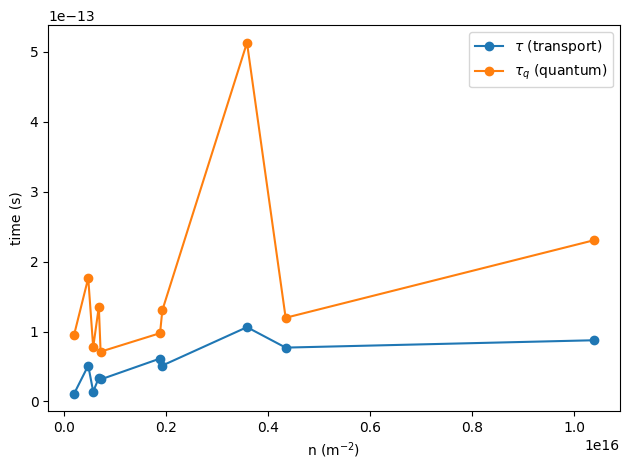

In [182]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

e = 1.602176634e-19
hbar = 1.054571817e-34
vF = 1e6

tau_values = []
tauq_values = []
n_values = []


import numpy as np

def extract_B_onset(x, y, threshold=0.15):
    """
    x = 1/B (sorted)
    y = detrended Rxx
    returns B_onset where oscillations become visible
    """

    # gradient-based signal strength
    dy = np.gradient(y)
    signal = np.abs(dy)

    # normalize
    if np.max(signal) == 0:
        return np.nan

    signal = signal / np.max(signal)

    idx = np.where(signal > threshold)[0]

    if len(idx) == 0:
        return np.nan

    return 1 / x[idx[0]]

for VG in gate_voltages:

    Binv = pd.to_numeric(df[f"Binv_{VG}"], errors="coerce").values
    Rxx  = pd.to_numeric(df[f"Rxx_{VG}"], errors="coerce").values

    VG_float = float(VG.replace("V", ""))

    if VG_float not in n_dict or VG_float not in tauq_dict:
        continue

    n = n_dict[VG_float]
    tau_q = tauq_dict[VG_float]

    idx = np.argsort(Binv)
    x = Binv[idx]
    y = Rxx[idx]

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    y_osc = detrend(y)

    B_onset = extract_B_onset(x, y_osc)

    if np.isfinite(B_onset):
        mu = 1 / B_onset

        kF = np.sqrt(np.pi * n)
        m_star = hbar * kF / vF

        tau = (mu * m_star) / e
    else:
        tau = np.nan

    tau_values.append(tau)
    tauq_values.append(tau_q)
    n_values.append(n)

# sort by n
n_values, tau_values, tauq_values = zip(*sorted(zip(n_values, tau_values, tauq_values)))

plt.figure()
plt.plot(n_values, tau_values, marker='o', label=r'$\tau$ (transport)')
plt.plot(n_values, tauq_values, marker='o', label=r'$\tau_q$ (quantum)')

plt.xlabel("n (m$^{-2}$)")
plt.ylabel("time (s)")
plt.legend()
plt.tight_layout()
plt.show()

In [183]:
print(f'tau_values: {tau_values}')
print(f'tauq_values: {tauq_values}')

tau_values: (np.float64(1.1195724800530945e-14), np.float64(5.1263778565870736e-14), np.float64(1.4050538225156598e-14), np.float64(3.372501843897038e-14), np.float64(3.141692993094767e-14), np.float64(6.131093208255142e-14), np.float64(5.1326723204953873e-14), np.float64(1.0624131542061494e-13), np.float64(7.698474939816877e-14), np.float64(8.749850265329663e-14))
tauq_values: (np.float64(9.558548545696939e-14), np.float64(1.764652783362466e-13), np.float64(7.731098690547974e-14), np.float64(1.3561278157242747e-13), np.float64(7.114300092811682e-14), np.float64(9.762663937877793e-14), np.float64(1.304231228473996e-13), np.float64(5.132696722481585e-13), np.float64(1.1966609415979522e-13), np.float64(2.3063486539476235e-13))


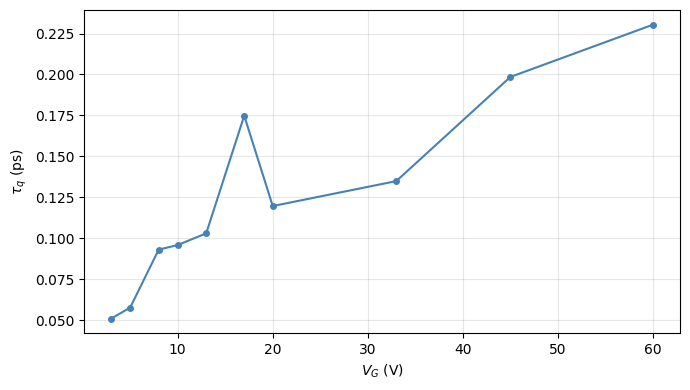

In [184]:
tauq_dict = {}

for VG in gate_voltages:
    try:
        Binv = pd.to_numeric(df[f"Binv_{VG}"], errors="coerce").values
        Rxx  = pd.to_numeric(df[f"Rxx_{VG}"],  errors="coerce").values
    except KeyError:
        continue

    idx  = np.argsort(Binv)
    x, y = Binv[idx], Rxx[idx]
    mask = np.isfinite(x) & np.isfinite(y) & (Binv[idx] < 5)
    x, y = x[mask], y[mask]

    if len(x) < 10:
        continue

    VG_float = float(VG.replace("V", ""))
    
    t = (VG_float - VG_numeric.min()) / (VG_numeric.max() - VG_numeric.min())
    color = cmap(t)

    traces.append((VG_float, x, y, color))

    dx          = np.mean(np.diff(x))
    y_detrended = detrend(y)
    yf          = fft(y_detrended)
    xf          = fftfreq(len(x), d=dx)
    pos         = xf > 0
    xf, yf      = xf[pos], np.abs(yf[pos])
    if len(xf) == 0:
        continue
    F = xf[np.argmax(yf)]
    n_dict[VG_float] = (2 * e / h) * F

    # restrict further for Dingle fit
    dingle_mask = x < 4
    x_d, y_d = x[dingle_mask], y[dingle_mask]
    tauq_dict[VG_float] = extract_tauq_graphene(x_d, y_d, n_dict[VG_float])


# --- plot tau_q(VG) ---
tauq_sorted = dict(sorted(tauq_dict.items()))
vg_tq  = np.array(list(tauq_sorted.keys()))
tauq   = np.array(list(tauq_sorted.values())) * 1e12   # convert to ps

fig_tq, ax_tq = plt.subplots(figsize=(7, 4))
ax_tq.plot(vg_tq, tauq, lw=1.5, marker="o", ms=4, color="steelblue")
ax_tq.set_xlabel(r"$V_G$ (V)")
ax_tq.set_ylabel(r"$\tau_q$ (ps)")
ax_tq.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig_tq.savefig('tau_q_vs_VG.png', dpi=300)

In [185]:

print(f"tau_q values (ps): {np.mean(np.array(list(tauq_dict.values()))) * 1e12} pm {np.std(np.array(list(tauq_dict.values()))) * 1e12} ps")

tau_q values (ps): 0.12588322147136344 pm 0.05611039177467144 ps


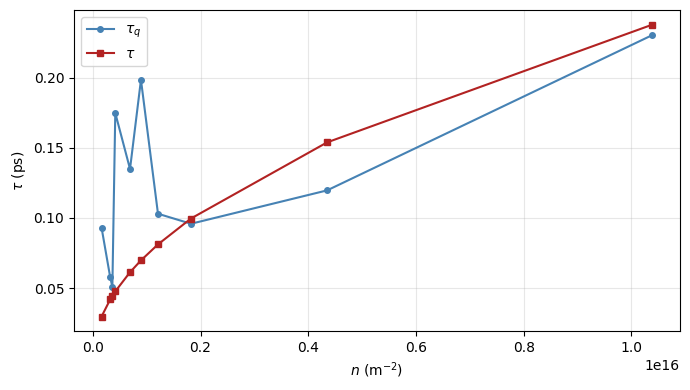

In [ ]:
mu_tr = 2
mu_rr_2 = 3
tauq_n  = {}
tautr_n = {}

for VG_float in tauq_dict:
    tauq = tauq_dict[VG_float]
    if not np.isfinite(tauq):
        continue
    if VG_float not in n_dict:
        continue
    n      = n_dict[VG_float]
    kF     = np.sqrt(np.pi * n)
    m_star = hbar * kF / vF
    tau_tr = m_star * mu_tr / e
    tauq_n[n]  = tauq
    tautr_n[n] = tau_tr

n_tauq  = np.array(sorted(tauq_n.keys()))
tq_vals = np.array([tauq_n[k]  for k in n_tauq])  * 1e12  # ps

n_tautr  = np.array(sorted(tautr_n.keys()))
tr_vals  = np.array([tautr_n[k] for k in n_tautr]) * 1e12  # ps

fig_tau, ax_tau = plt.subplots(figsize=(7, 4))
ax_tau.plot(n_tauq,  tq_vals, lw=1.5, marker="o", ms=4,
            color="steelblue", label=r"$\tau_q$")
ax_tau.plot(n_tautr, tr_vals, lw=1.5, marker="s", ms=4,
            color="firebrick", label=r"$\tau$")

ax_tau.set_xlabel(r"$n$ (m$^{-2}$)")
ax_tau.set_ylabel(r"$\tau$ (ps)")
ax_tau.legend()
ax_tau.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig_tau.savefig('tau_q_tr_vs_n.png', dpi=300)

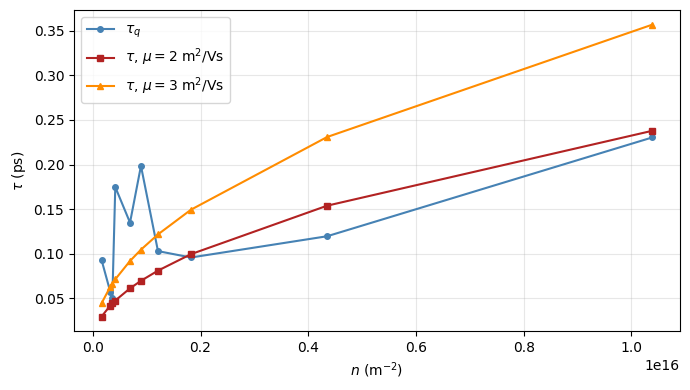

In [196]:
mu_tr   = 2.0
mu_tr_2 = 3.0

tauq_n   = {}
tautr_n  = {}
tautr_n2 = {}

for VG_float in tauq_dict:
    tauq = tauq_dict[VG_float]
    if not np.isfinite(tauq):
        continue
    if VG_float not in n_dict:
        continue
    n      = n_dict[VG_float]
    kF     = np.sqrt(np.pi * n)
    m_star = hbar * kF / vF
    tauq_n[n]   = tauq
    tautr_n[n]  = m_star * mu_tr   / e
    tautr_n2[n] = m_star * mu_tr_2 / e

n_tauq  = np.array(sorted(tauq_n.keys()))
tq_vals = np.array([tauq_n[k]   for k in n_tauq])  * 1e12

n_tautr  = np.array(sorted(tautr_n.keys()))
tr_vals  = np.array([tautr_n[k]  for k in n_tautr]) * 1e12
tr_vals2 = np.array([tautr_n2[k] for k in n_tautr]) * 1e12

fig_tau, ax_tau = plt.subplots(figsize=(7, 4))
ax_tau.plot(n_tauq,  tq_vals,  lw=1.5, marker="o", ms=4,
            color="steelblue", label=r"$\tau_q$")
ax_tau.plot(n_tautr, tr_vals,  lw=1.5, marker="s", ms=4,
            color="firebrick", label=r"$\tau$, $\mu=2$ m$^2$/Vs")
ax_tau.plot(n_tautr, tr_vals2, lw=1.5, marker="^", ms=4,
            color="darkorange", label=r"$\tau$, $\mu=3$ m$^2$/Vs")

ax_tau.set_xlabel(r"$n$ (m$^{-2}$)")
ax_tau.set_ylabel(r"$\tau$ (ps)")
ax_tau.legend()
ax_tau.grid(alpha=0.3)
plt.tight_layout()
fig_tau.savefig('tau_q_tr_vs_n.png', dpi=300)
plt.show()